In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("titanic.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [ ]:
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [ ]:
df.shape

(887, 8)

In [ ]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(887, 8)


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)

print(df.isnull().sum())

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


/tmp/ipykernel_1009/3912786769.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
Siblings/Spouses Aboard,int64
Parents/Children Aboard,int64
Fare,float64


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
Siblings/Spouses Aboard,0
Parents/Children Aboard,0
Fare,0


In [ ]:
df.describe()


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


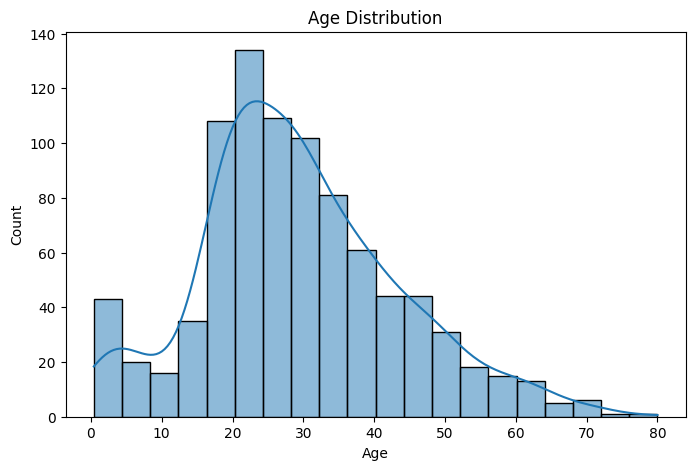

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

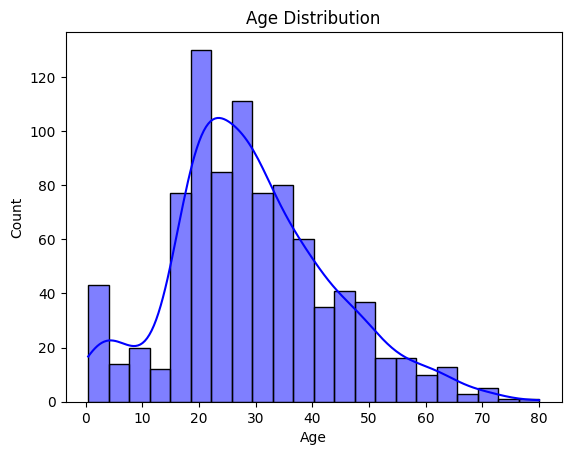

In [ ]:
sns.histplot(df['Age'].dropna(), kde=True, color='blue')
plt.title('Age Distribution')
plt.show()

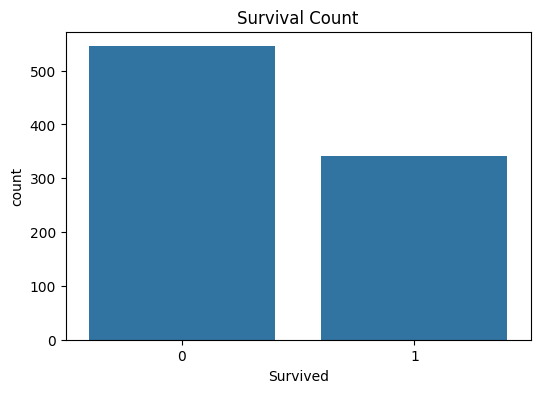

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

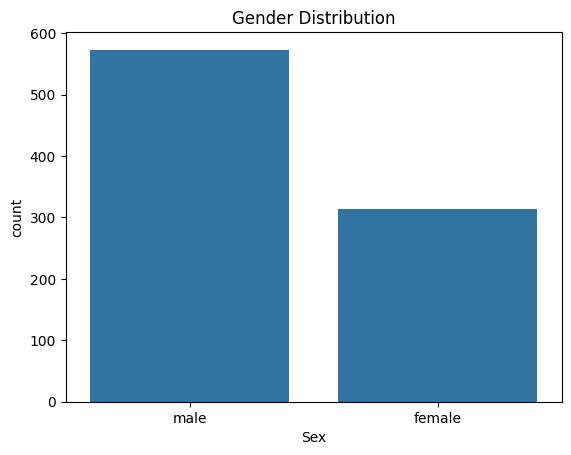

In [ ]:
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

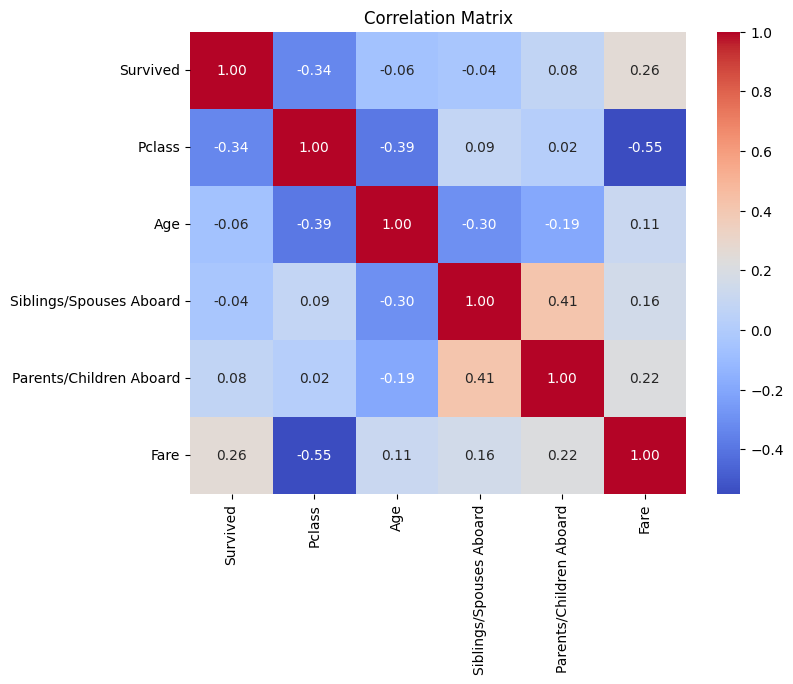

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

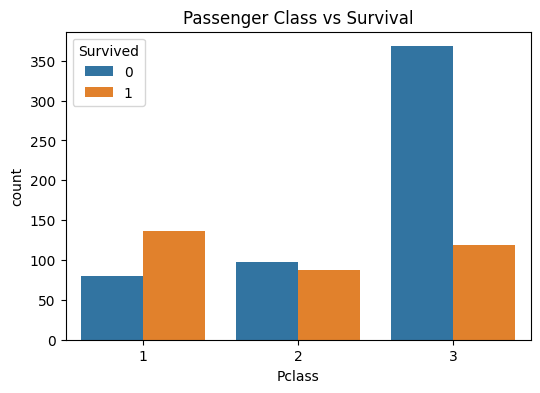

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

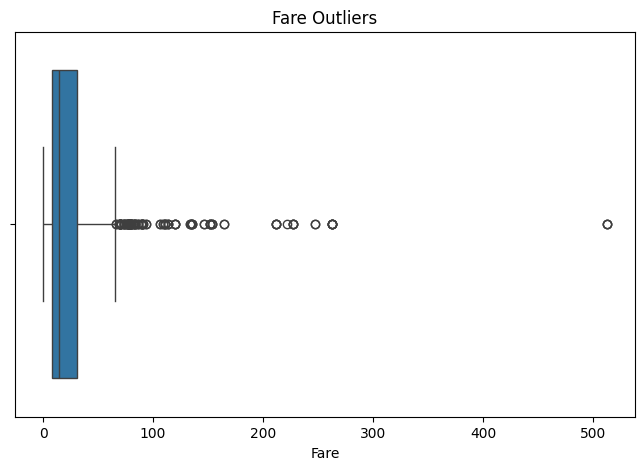

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()

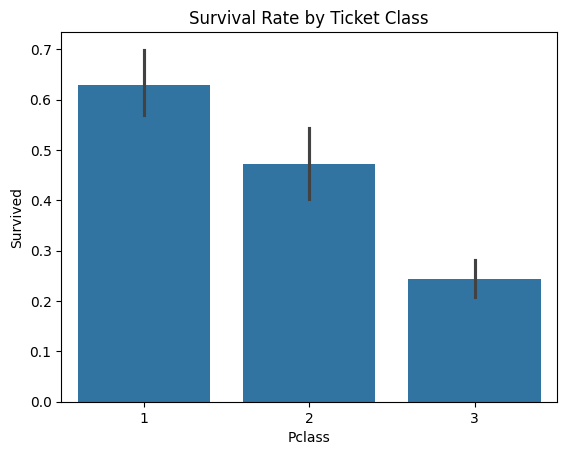

In [ ]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Ticket Class')
plt.show()

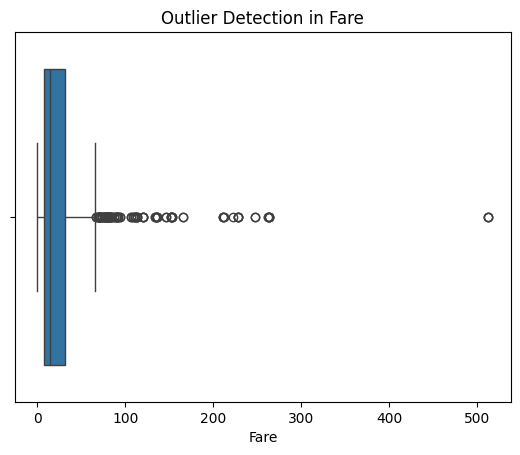

In [ ]:
sns.boxplot(x=df['Fare'])
plt.title('Outlier Detection in Fare')
plt.show()

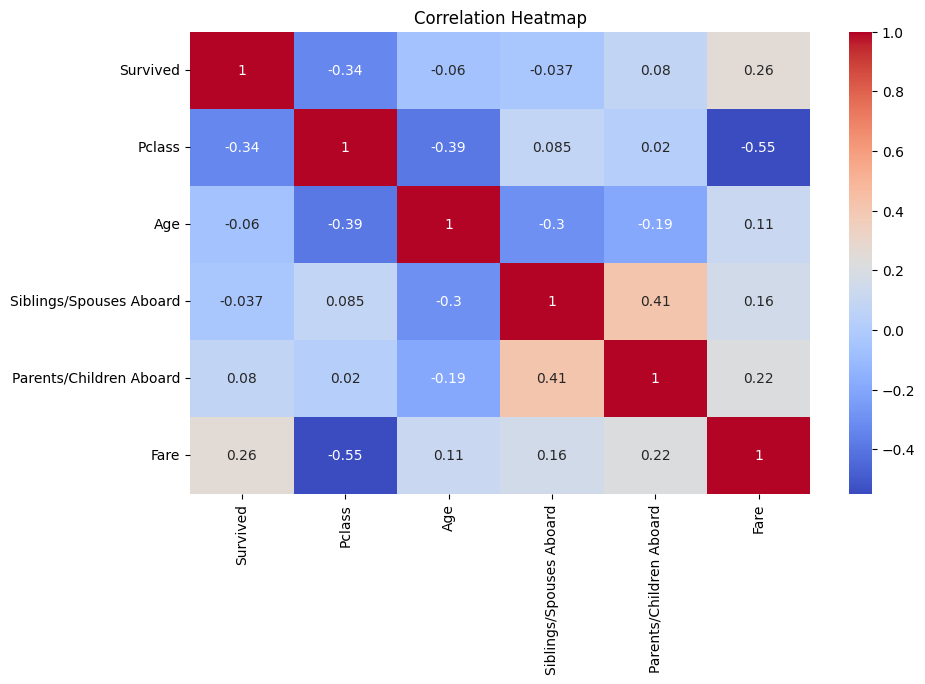

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Age Skewness :", df['Age'].skew())
print("Age Kurtosis :", df['Age'].kurt())

Age Skewness : 0.44718857190799916
Age Kurtosis : 0.2925590867837582


In [ ]:
print(df[['Age','Fare']].corr(method='pearson'))

           Age      Fare
Age   1.000000  0.112329
Fare  0.112329  1.000000


In [ ]:
print(df[['Age','Fare']].corr(method='spearman'))

           Age      Fare
Age   1.000000  0.156062
Fare  0.156062  1.000000


In [ ]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 116


In [ ]:
from scipy import stats

z_scores = np.abs(stats.zscore(df['Fare']))

outliers = df[z_scores > 3]

print("Outliers using Z-Score:", len(outliers))

Outliers using Z-Score: 20


In [ ]:
print("Average Survival Rate by Class")
print(df.groupby('Pclass')['Survived'].mean())

Average Survival Rate by Class
Pclass
1    0.629630
2    0.472826
3    0.244353
Name: Survived, dtype: float64


In [ ]:
print("Average Survival Rate by Age")
print(df.groupby(pd.cut(df['Age'], bins=5))['Survived'].mean())

Average Survival Rate by Age
Age
(0.34, 16.336]      0.517544
(16.336, 32.252]    0.348786
(32.252, 48.168]    0.408696
(48.168, 64.084]    0.389610
(64.084, 80.0]      0.076923
Name: Survived, dtype: float64


/tmp/ipykernel_1009/1947986790.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df['Age'], bins=5))['Survived'].mean())


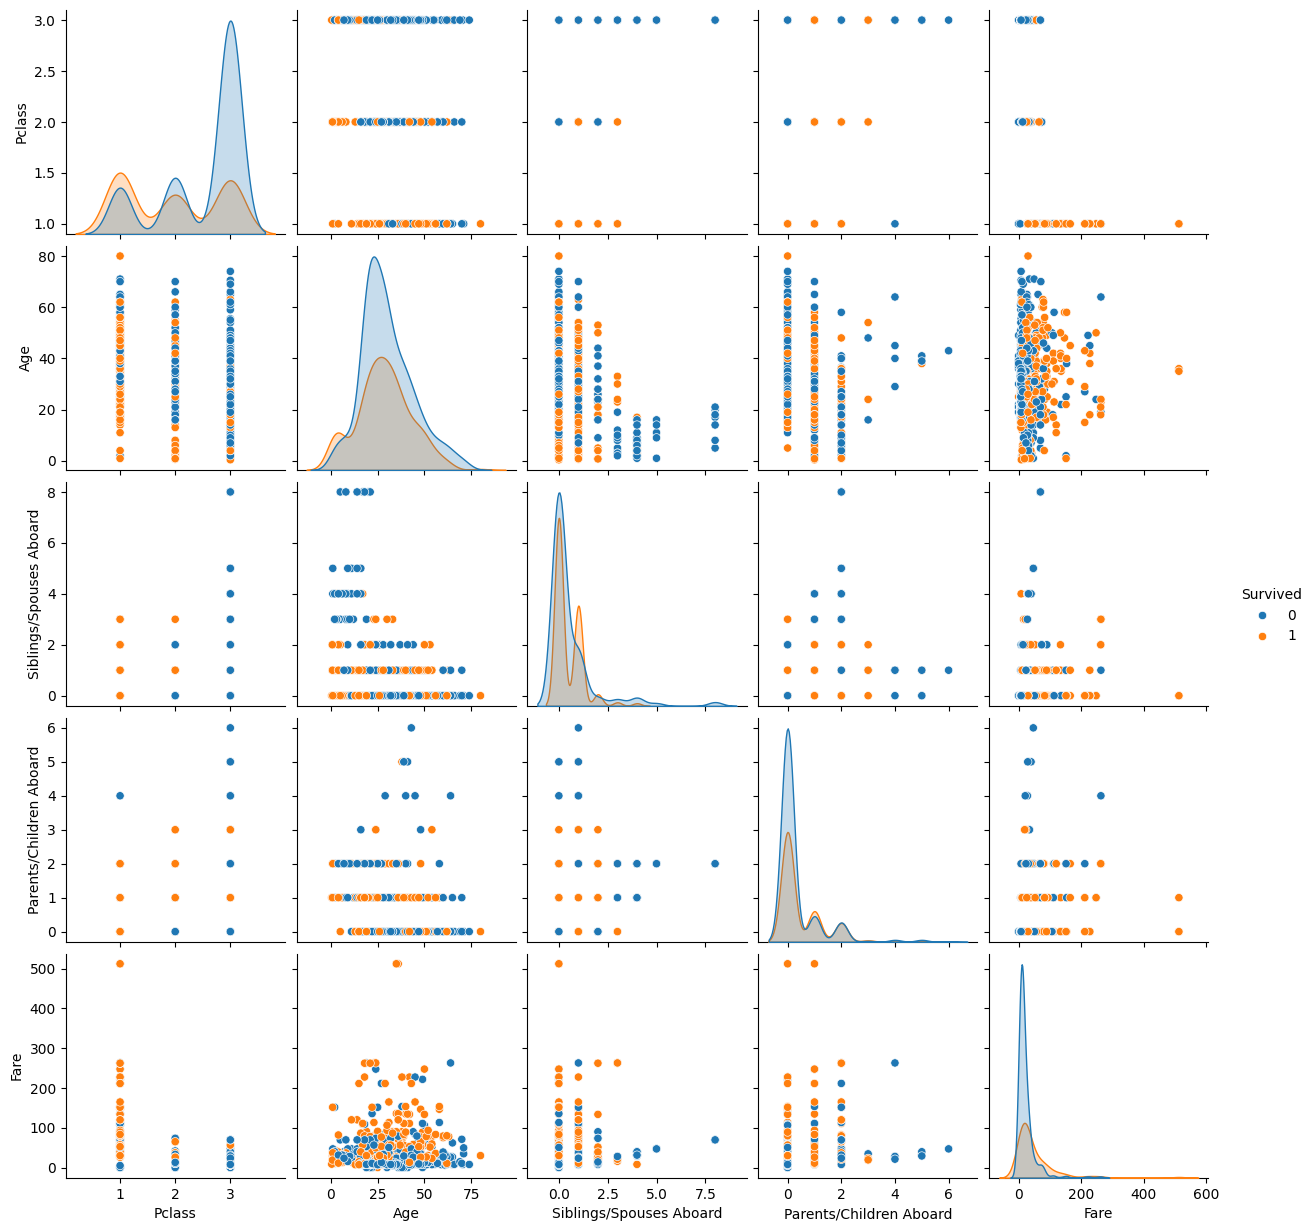

In [ ]:
sns.pairplot(df, hue='Survived', diag_kind='kde')
plt.show()

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

In [ ]:
from google.colab import files

files.download("titanic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>